# Bank Customer Churn Prediction
## Identifying At-Risk Customers in Retail Banking

Customer churn is one of the most significant challenges facing retail banks. Retaining an existing customer costs significantly less than acquiring a new one, yet most banks lack the analytical tools to identify at-risk customers before they leave.
This project uses machine learning to predict which bank customers are most likely to close their accounts, and more importantly, why, giving business leaders the insight to intervene with targeted retention strategies before churn occurs.
Using 10,000 customer records containing demographic profiles, account behaviour and product usage patterns, the analysis uncovers the key drivers of customer churn and builds a predictive model to support retention strategy decisions at senior and board level.
This project demonstrates a scalable customer churn prediction methodology applicable across retail banking, financial services and any account based business operating at scale.


**Analyst:** Kingsley Eboh<br>
**Dataset:** Bank Customer Churn Dataset | 10,000 customer records<br>
**Domain:** Retail Banking | Customer Retention and Financial Services Analytics<br>
**Stack:** Python | PostgreSQL | Power BI<br>

## Section 1: Import Libraries
pandas, numpy, matplotlib, seaborn, scikit-learn, xgboost and shap 
were imported to support data loading, cleaning, visualisation, 
machine learning model development and model interpretation 
throughout the analysis.

In [24]:
# Data manipulation
import pandas as pd
import numpy as np
import os

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
import shap

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Set working directory
os.chdir('/home/king/projects/bank-churn-prediction')
print(f"Working directory: {os.getcwd()}")
print("All libraries imported successfully")

Working directory: /home/king/projects/bank-churn-prediction
All libraries imported successfully


## Section 2: Load and Explore Data
The dataset was loaded from the data folder and inspected to understand 
its structure, dimensions, column types and basic statistical properties 
before proceeding to data quality assessment and cleaning.

In [25]:
df = pd.read_csv('data/Churn_Modelling.xls')

# Basic inspection
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== BASIC STATISTICS ===")
print(df.describe())

print("\n=== TARGET VARIABLE DISTRIBUTION ===")
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100
print(f"Stayed (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"Churned (1): {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")

=== DATASET OVERVIEW ===
Shape: (10000, 14)
Rows: 10,000
Columns: 14

=== COLUMN NAMES ===
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

=== DATA TYPES ===
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

=== FIRST 5 ROWS ===
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42 

## Section 3: Data Quality Assessment
The dataset was assessed for missing values, duplicate records, 
data type consistency and outliers to ensure the data was complete 
and reliable before cleaning and modelling.

In [26]:

print("=== DATA QUALITY ASSESSMENT ===\n")

# Missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct.round(2)
})
print(missing_df)

# Duplicate records
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Unique values per column
print("\nUnique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")

# Check categorical distributions
print("\nGeography distribution:")
print(df['Geography'].value_counts())

print("\nGender distribution:")
print(df['Gender'].value_counts())

print("\nNumOfProducts distribution:")
print(df['NumOfProducts'].value_counts())

# Check zero balance customers
zero_balance = (df['Balance'] == 0).sum()
print(f"\nCustomers with zero balance: {zero_balance:,} ({zero_balance/len(df)*100:.1f}%)")

# Age distribution check
print(f"\nAge range: {df['Age'].min()} to {df['Age'].max()}")
print(f"Mean age: {df['Age'].mean():.1f}")

# Credit score check
print(f"\nCredit score range: {df['CreditScore'].min()} to {df['CreditScore'].max()}")
print(f"Mean credit score: {df['CreditScore'].mean():.1f}")

print("\n=== DATA QUALITY ASSESSMENT COMPLETE ===")

=== DATA QUALITY ASSESSMENT ===

Missing values per column:
                 Missing Count  Missing Percentage
RowNumber                    0                0.00
CustomerId                   0                0.00
Surname                      0                0.00
CreditScore                  0                0.00
Geography                    0                0.00
Gender                       0                0.00
Age                          0                0.00
Tenure                       0                0.00
Balance                      0                0.00
NumOfProducts                0                0.00
HasCrCard                    0                0.00
IsActiveMember               0                0.00
EstimatedSalary              0                0.00
Exited                       0                0.00

Duplicate rows: 0

Unique values per column:
  RowNumber: 10000 unique values
  CustomerId: 10000 unique values
  Surname: 2932 unique values
  CreditScore: 460 unique values

## Section 4: Data Cleaning
Irrelevant columns were removed, categorical variables were encoded 
and features were prepared for machine learning model development.

In [27]:

# Drop irrelevant columns
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print(f"Columns after dropping irrelevant fields: {df_clean.columns.tolist()}")

# Encode categorical variables
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])
print(f"\nGender encoding: Female=0, Male=1")
print(df_clean['Gender'].value_counts())

# One hot encode Geography
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)
print(f"\nGeography columns after encoding:")
print([col for col in df_clean.columns if 'Geography' in col])

# Final shape
print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

# Check class balance
print(f"\nTarget variable distribution:")
print(df_clean['Exited'].value_counts())
print(f"Churn rate: {df_clean['Exited'].mean()*100:.1f}%")

print("\n=== DATA CLEANING COMPLETE ===")

Columns after dropping irrelevant fields: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Gender encoding: Female=0, Male=1
Gender
1    5457
0    4543
Name: count, dtype: int64

Geography columns after encoding:
['Geography_Germany', 'Geography_Spain']

Final dataset shape: (10000, 12)
Columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']

Target variable distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn rate: 20.4%

=== DATA CLEANING COMPLETE ===


## Section 5a: Exploratory Data Analysis
The cleaned dataset was analysed to understand the distribution of 
key features and their relationship with customer churn. Visual 
analysis was used to identify patterns and potential predictors 
of churn behaviour.

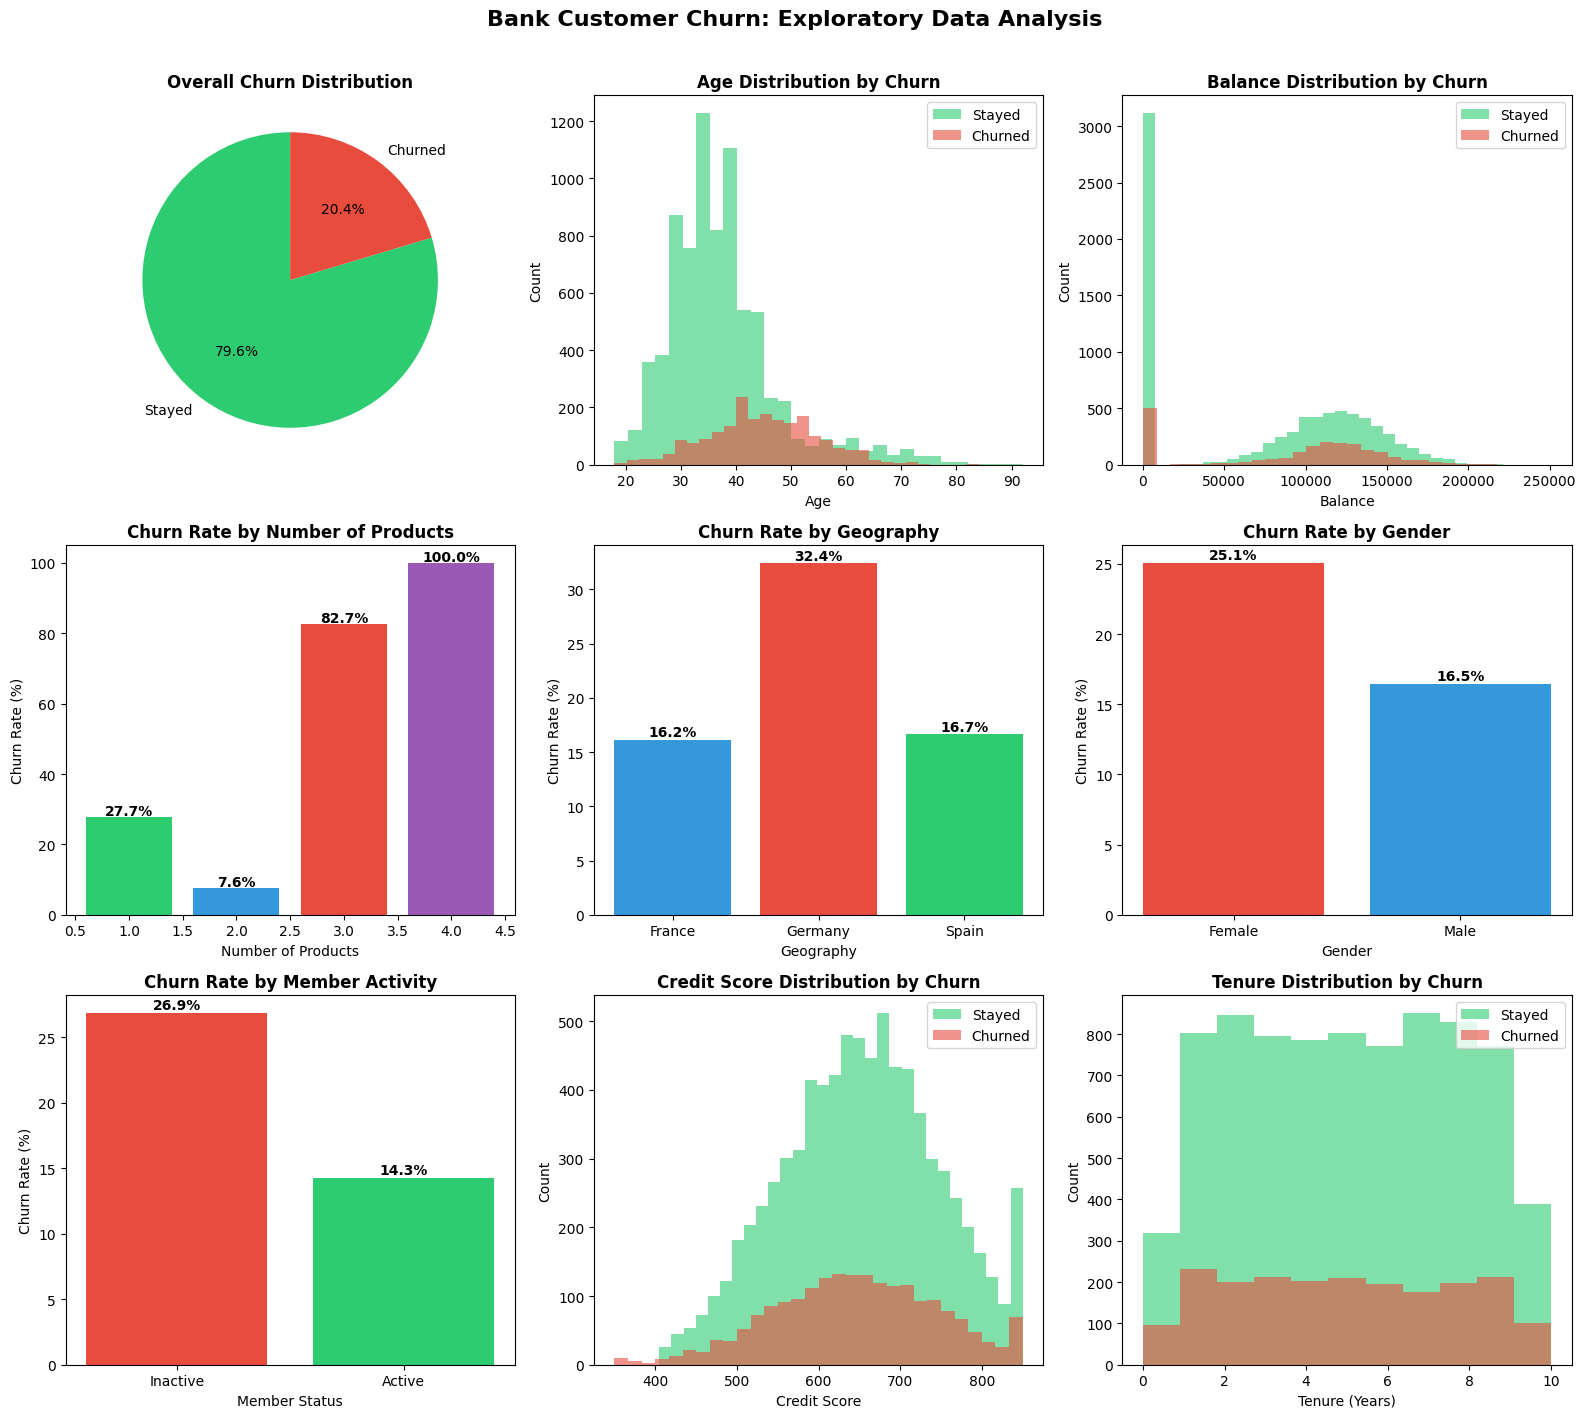

EDA complete

Key findings:
Germany churn rate: 32.4%
France churn rate: 16.2%
Spain churn rate: 16.7%
Female churn rate: 25.1%
Male churn rate: 16.5%
Active member churn rate: 14.3%
Inactive member churn rate: 26.9%


In [28]:

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Bank Customer Churn: Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=1.01)

# 1: Churn Distribution
churn_counts = df_clean['Exited'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0,0].pie(churn_counts, labels=['Stayed', 'Churned'],
              autopct='%1.1f%%', colors=colors, startangle=90)
axes[0,0].set_title('Overall Churn Distribution', fontweight='bold')

# 2: Age Distribution by Churn
axes[0,1].hist(df_clean[df_clean['Exited']==0]['Age'],
               bins=30, alpha=0.6, color='#2ecc71', label='Stayed')
axes[0,1].hist(df_clean[df_clean['Exited']==1]['Age'],
               bins=30, alpha=0.6, color='#e74c3c', label='Churned')
axes[0,1].set_title('Age Distribution by Churn', fontweight='bold')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# 3: Balance Distribution by Churn
axes[0,2].hist(df_clean[df_clean['Exited']==0]['Balance'],
               bins=30, alpha=0.6, color='#2ecc71', label='Stayed')
axes[0,2].hist(df_clean[df_clean['Exited']==1]['Balance'],
               bins=30, alpha=0.6, color='#e74c3c', label='Churned')
axes[0,2].set_title('Balance Distribution by Churn', fontweight='bold')
axes[0,2].set_xlabel('Balance')
axes[0,2].set_ylabel('Count')
axes[0,2].legend()

# 4: Churn Rate by Number of Products
products_churn = df_clean.groupby('NumOfProducts')['Exited'].mean() * 100
axes[1,0].bar(products_churn.index, products_churn.values,
              color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
axes[1,0].set_title('Churn Rate by Number of Products', fontweight='bold')
axes[1,0].set_xlabel('Number of Products')
axes[1,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(products_churn.values):
    axes[1,0].text(products_churn.index[i], v + 0.5,
                   f'{v:.1f}%', ha='center', fontweight='bold')

# 5: Churn Rate by Geography
geo_labels = ['France', 'Germany', 'Spain']
france_churn = df[df['Geography']=='France']['Exited'].mean() * 100
germany_churn = df[df['Geography']=='Germany']['Exited'].mean() * 100
spain_churn = df[df['Geography']=='Spain']['Exited'].mean() * 100
geo_churn = [france_churn, germany_churn, spain_churn]
bars = axes[1,1].bar(geo_labels, geo_churn,
                     color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1,1].set_title('Churn Rate by Geography', fontweight='bold')
axes[1,1].set_xlabel('Geography')
axes[1,1].set_ylabel('Churn Rate (%)')
for bar, v in zip(bars, geo_churn):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 6: Churn Rate by Gender
gender_churn = df_clean.groupby('Gender')['Exited'].mean() * 100
gender_labels = ['Female', 'Male']
bars = axes[1,2].bar(gender_labels, gender_churn.values,
                     color=['#e74c3c', '#3498db'])
axes[1,2].set_title('Churn Rate by Gender', fontweight='bold')
axes[1,2].set_xlabel('Gender')
axes[1,2].set_ylabel('Churn Rate (%)')
for bar, v in zip(bars, gender_churn.values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 7: Churn Rate by Active Member
active_churn = df_clean.groupby('IsActiveMember')['Exited'].mean() * 100
active_labels = ['Inactive', 'Active']
bars = axes[2,0].bar(active_labels, active_churn.values,
                     color=['#e74c3c', '#2ecc71'])
axes[2,0].set_title('Churn Rate by Member Activity', fontweight='bold')
axes[2,0].set_xlabel('Member Status')
axes[2,0].set_ylabel('Churn Rate (%)')
for bar, v in zip(bars, active_churn.values):
    axes[2,0].text(bar.get_x() + bar.get_width()/2,
                   v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 8: Credit Score Distribution by Churn
axes[2,1].hist(df_clean[df_clean['Exited']==0]['CreditScore'],
               bins=30, alpha=0.6, color='#2ecc71', label='Stayed')
axes[2,1].hist(df_clean[df_clean['Exited']==1]['CreditScore'],
               bins=30, alpha=0.6, color='#e74c3c', label='Churned')
axes[2,1].set_title('Credit Score Distribution by Churn', fontweight='bold')
axes[2,1].set_xlabel('Credit Score')
axes[2,1].set_ylabel('Count')
axes[2,1].legend()

# 9: Tenure Distribution by Churn
axes[2,2].hist(df_clean[df_clean['Exited']==0]['Tenure'],
               bins=11, alpha=0.6, color='#2ecc71', label='Stayed')
axes[2,2].hist(df_clean[df_clean['Exited']==1]['Tenure'],
               bins=11, alpha=0.6, color='#e74c3c', label='Churned')
axes[2,2].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[2,2].set_xlabel('Tenure (Years)')
axes[2,2].set_ylabel('Count')
axes[2,2].legend()

plt.tight_layout()
plt.savefig('figures/analysis1_exploratory_data_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("EDA complete")
print(f"\nKey findings:")
print(f"Germany churn rate: {germany_churn:.1f}%")
print(f"France churn rate: {france_churn:.1f}%")
print(f"Spain churn rate: {spain_churn:.1f}%")
print(f"Female churn rate: {gender_churn[0]:.1f}%")
print(f"Male churn rate: {gender_churn[1]:.1f}%")
print(f"Active member churn rate: {active_churn[1]:.1f}%")
print(f"Inactive member churn rate: {active_churn[0]:.1f}%")

## Section 5b: Zero Balance and High Value Customer Analysis

A significant proportion of customers in the dataset held a zero account balance. This segment was analysed separately to determine whether zero balance customers behave differently from customers with a positive balance, given the direct implications for customer lifetime value and retention prioritisation.

=== ZERO BALANCE VS POSITIVE BALANCE CHURN ANALYSIS ===

Zero balance customers: 3,617 (36.2%)
Positive balance customers: 6,383 (63.8%)

Zero balance churn rate: 13.8%
Positive balance churn rate: 24.1%

Average balance of churned customers: £91,108.54
Average balance of stayed customers: £72,745.30

High value threshold (75th percentile): £127,644.24
High value churners: 592
High value churn rate: 23.7%
Average balance of high value churners: £149,754.95


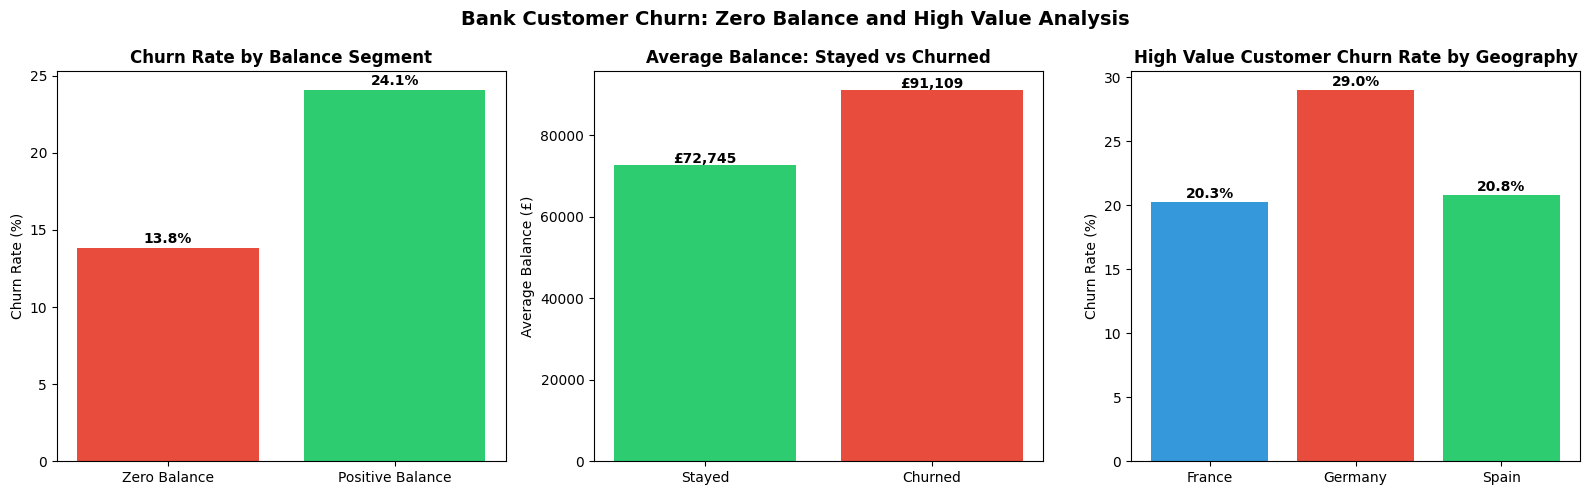


Figure saved to figures/analysis2_zero_balance_high_value.png


In [30]:

# Churn rate by balance segment
zero_churn = df[df['Balance']==0]['Exited'].mean() * 100
positive_churn = df[df['Balance']>0]['Exited'].mean() * 100

print("=== ZERO BALANCE VS POSITIVE BALANCE CHURN ANALYSIS ===\n")
print(f"Zero balance customers: {(df['Balance']==0).sum():,} ({(df['Balance']==0).mean()*100:.1f}%)")
print(f"Positive balance customers: {(df['Balance']>0).sum():,} ({(df['Balance']>0).mean()*100:.1f}%)")
print(f"\nZero balance churn rate: {zero_churn:.1f}%")
print(f"Positive balance churn rate: {positive_churn:.1f}%")

# Average balance of churned vs stayed
print(f"\nAverage balance of churned customers: £{df[df['Exited']==1]['Balance'].mean():,.2f}")
print(f"Average balance of stayed customers: £{df[df['Exited']==0]['Balance'].mean():,.2f}")

# High value customer analysis
high_value_threshold = df['Balance'].quantile(0.75)
high_value_churners = df[(df['Balance'] >= high_value_threshold) & (df['Exited'] == 1)]
print(f"\nHigh value threshold (75th percentile): £{high_value_threshold:,.2f}")
print(f"High value churners: {len(high_value_churners):,}")
print(f"High value churn rate: {len(high_value_churners)/len(df[df['Balance'] >= high_value_threshold])*100:.1f}%")
print(f"Average balance of high value churners: £{high_value_churners['Balance'].mean():,.2f}")

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bank Customer Churn: Zero Balance and High Value Analysis',
             fontsize=14, fontweight='bold')

# Plot 1: Churn rate by balance segment
segments = ['Zero Balance', 'Positive Balance']
churn_rates = [zero_churn, positive_churn]
bars = axes[0].bar(segments, churn_rates, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Churn Rate by Balance Segment', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for bar, v in zip(bars, churn_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 2: Average balance churned vs stayed
groups = ['Stayed', 'Churned']
avg_balances = [
    df[df['Exited']==0]['Balance'].mean(),
    df[df['Exited']==1]['Balance'].mean()
]
bars = axes[1].bar(groups, avg_balances, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Average Balance: Stayed vs Churned', fontweight='bold')
axes[1].set_ylabel('Average Balance (£)')
for bar, v in zip(bars, avg_balances):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 500, f'£{v:,.0f}', ha='center', fontweight='bold')

# Plot 3: High value customer churn rate by geography
geo_high_value = df[df['Balance'] >= high_value_threshold].copy()
geo_hv_churn = geo_high_value.groupby('Geography')['Exited'].mean() * 100
bars = axes[2].bar(geo_hv_churn.index, geo_hv_churn.values,
                   color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('High Value Customer Churn Rate by Geography', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
for bar, v in zip(bars, geo_hv_churn.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/analysis2_zero_balance_high_value.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to figures/analysis2_zero_balance_high_value.png")

## Section 5c: Dormant Account Analysis

A dormant account was defined as a customer holding a zero balance, classified as inactive and holding only one product. This segment was isolated to determine whether dormant customers represent a distinct churn risk profile from genuinely engaged customers, and to assess the extent to which their inclusion may have influenced the overall churn rate reported in the analysis.

=== DORMANT ACCOUNT ANALYSIS ===

Dormant accounts: 473 (4.7%)
Engaged customers: 9,527 (95.3%)

Overall churn rate: 20.4%
Dormant account churn rate: 47.1%
Engaged customer churn rate: 19.0%

Dormant account profile:
Average age: 40.3
Average credit score: 645.9
Average tenure: 5.0 years

Dormant account geography breakdown:
Geography
France    318
Spain     155
Name: count, dtype: int64

Dormant account gender breakdown:
Gender
Male      243
Female    230
Name: count, dtype: int64


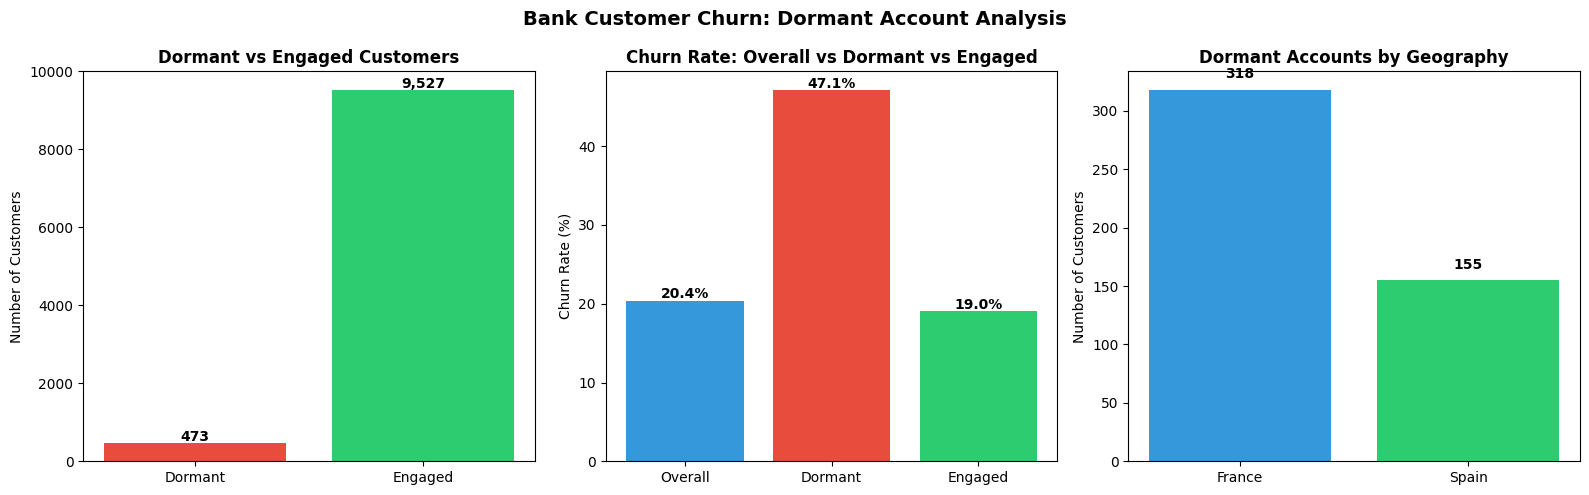


Figure saved to figures/analysis3_dormant_account_analysis.png


In [42]:

# Define dormant account flag
dormant = (df['Balance'] == 0) & (df['IsActiveMember'] == 0) & (df['NumOfProducts'] == 1)
df_dormant = df[dormant].copy()
df_engaged = df[~dormant].copy()

print("=== DORMANT ACCOUNT ANALYSIS ===\n")
print(f"Dormant accounts: {dormant.sum():,} ({dormant.mean()*100:.1f}%)")
print(f"Engaged customers: {(~dormant).sum():,} ({(~dormant).mean()*100:.1f}%)")

# Churn rate comparison
dormant_churn = df_dormant['Exited'].mean() * 100
engaged_churn = df_engaged['Exited'].mean() * 100
overall_churn = df['Exited'].mean() * 100

print(f"\nOverall churn rate: {overall_churn:.1f}%")
print(f"Dormant account churn rate: {dormant_churn:.1f}%")
print(f"Engaged customer churn rate: {engaged_churn:.1f}%")

# Dormant account profile
print(f"\nDormant account profile:")
print(f"Average age: {df_dormant['Age'].mean():.1f}")
print(f"Average credit score: {df_dormant['CreditScore'].mean():.1f}")
print(f"Average tenure: {df_dormant['Tenure'].mean():.1f} years")

print(f"\nDormant account geography breakdown:")
print(df_dormant['Geography'].value_counts())

print(f"\nDormant account gender breakdown:")
print(df_dormant['Gender'].value_counts())

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bank Customer Churn: Dormant Account Analysis',
             fontsize=14, fontweight='bold')

# Plot 1: Dormant vs engaged customer count
segments = ['Dormant', 'Engaged']
counts = [dormant.sum(), (~dormant).sum()]
bars = axes[0].bar(segments, counts, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Dormant vs Engaged Customers', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 50, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Churn rate comparison
churn_segments = ['Overall', 'Dormant', 'Engaged']
churn_rates = [overall_churn, dormant_churn, engaged_churn]
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[1].bar(churn_segments, churn_rates, color=colors)
axes[1].set_title('Churn Rate: Overall vs Dormant vs Engaged', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for bar, v in zip(bars, churn_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 3: Dormant account geography distribution
geo_counts = df_dormant['Geography'].value_counts()
axes[2].bar(geo_counts.index, geo_counts.values,
            color=['#3498db', '#2ecc71', '#e74c3c'])
axes[2].set_title('Dormant Accounts by Geography', fontweight='bold')
axes[2].set_ylabel('Number of Customers')
for i, v in enumerate(geo_counts.values):
    axes[2].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/analysis3_dormant_account_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to figures/analysis3_dormant_account_analysis.png")

## Section 6: Derive three new features from age, balance, salary and product activity

Three interaction features are created to capture combined risk signals not present in the original columns. Balance_to_Salary captures relative wealth, Products Activity captures engagement depth, and Age Balance captures the older high-balance risk group.

In [31]:

df_model = df_clean.copy()

# Feature 1: Balance to Salary 
df_model['Balance_to_Salary'] = np.log1p(df_model['Balance'] / (df_model['EstimatedSalary'] + 1))

# Feature 2: Products Activity 
df_model['Products_Activity'] = df_model['NumOfProducts'] * df_model['IsActiveMember']

# Feature 3: Age Balance 
df_model['Age_Balance'] = df_model['Age'] * df_model['Balance']

# Validate shape
print("Shape after feature engineering:", df_model.shape)
print("\nNew columns added:")
print(df_model[['Balance_to_Salary', 'Products_Activity', 'Age_Balance']].head(10))

# Validate no missing values introduced
print("\nMissing values in new features:")
print(df_model[['Balance_to_Salary', 'Products_Activity', 'Age_Balance']].isnull().sum())

# Descriptive stats for new features
print("\nDescriptive stats for engineered features:")
print(df_model[['Balance_to_Salary', 'Products_Activity', 'Age_Balance']].describe().round(2))

Shape after feature engineering: (10000, 15)

New columns added:
   Balance_to_Salary  Products_Activity  Age_Balance
0               0.00                  1         0.00
1               0.56                  1   3436122.26
2               0.88                  0   6705753.60
3               0.00                  0         0.00
4               0.95                  1   5396965.26
5               0.57                  0   5005254.32
6               0.00                  2         0.00
7               0.67                  0   3336355.46
8               1.06                  2   6250247.08
9               1.06                  1   3634304.76

Missing values in new features:
Balance_to_Salary    0
Products_Activity    0
Age_Balance          0
dtype: int64

Descriptive stats for engineered features:
       Balance_to_Salary  Products_Activity  Age_Balance
count           10000.00           10000.00     10000.00
mean                0.66               0.79   2995491.97
std                 0.

## Section 7a (i): Model Training and Evaluation

Three classification models are trained to predict customer churn: Logistic Regression as a baseline, Random Forest as an ensemble method, and XGBoost as the primary model. Class imbalance is handled using class_weight balanced for Logistic Regression and Random Forest, and scale_pos_weight for XGBoost. Models are evaluated on accuracy, precision, recall, F1 score and ROC-AUC.

In [32]:

# features and target was defined
X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

print(f"Features: {X.shape[1]} columns")
print(f"Target distribution: {y.value_counts().to_dict()}")

# test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate: {y_test.mean()*100:.1f}%")

# Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale_pos_weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nXGBoost scale_pos_weight: {scale_pos_weight:.2f}")

# Train Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# GBoost
xgb = XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

# Build metrics comparison table
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': round(accuracy_score(y_true, y_pred) * 100, 1),
        'Precision': round(precision_score(y_true, y_pred) * 100, 1),
        'Recall': round(recall_score(y_true, y_pred) * 100, 1),
        'F1 Score': round(f1_score(y_true, y_pred) * 100, 1),
        'ROC AUC': round(roc_auc_score(y_true, y_prob) * 100, 1)
    }

metrics = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, lr_pred, lr_prob),
    'Random Forest': get_metrics(y_test, rf_pred, rf_prob),
    'XGBoost': get_metrics(y_test, xgb_pred, xgb_prob)
}).T

print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(metrics.to_string())
print("\n=== MODEL TRAINING COMPLETE ===")

Features: 14 columns
Target distribution: {0: 7963, 1: 2037}

Train set: 8,000 rows
Test set: 2,000 rows
Train churn rate: 20.4%
Test churn rate: 20.3%

XGBoost scale_pos_weight: 3.91

=== MODEL PERFORMANCE COMPARISON ===
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     71.00      38.40   70.50     49.70    77.50
Random Forest           85.90      76.80   44.00     55.90    85.00
XGBoost                 82.80      57.10   63.10     60.00    83.70

=== MODEL TRAINING COMPLETE ===


## Section 7a (ii): Cross-Validated Model Performance

To produce a more robust performance estimate, five-fold cross-validated ROC-AUC scores were calculated for all three baseline models. Cross-validation reduces the risk of overfitting to a single train-test split and provides a more reliable indicator of how each model is likely to perform on unseen data.

In [41]:

from sklearn.model_selection import cross_val_score

print("=== FIVE-FOLD CROSS-VALIDATED ROC-AUC ===\n")

# Logistic Regression cross-validation
lr_cv = cross_val_score(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1
)

# Random Forest cross-validation
rf_cv = cross_val_score(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1
)

# XGBoost cross-validation
xgb_cv = cross_val_score(
    XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight,
                  random_state=42, eval_metric='logloss', verbosity=0),
    X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1
)

# Print results
cv_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'CV ROC-AUC Mean': [lr_cv.mean(), rf_cv.mean(), xgb_cv.mean()],
    'CV ROC-AUC Std': [lr_cv.std(), rf_cv.std(), xgb_cv.std()],
    'Min Fold': [lr_cv.min(), rf_cv.min(), xgb_cv.min()],
    'Max Fold': [lr_cv.max(), rf_cv.max(), xgb_cv.max()]
}).set_index('Model')

cv_results['CV ROC-AUC Mean'] = (cv_results['CV ROC-AUC Mean'] * 100).round(1)
cv_results['CV ROC-AUC Std'] = (cv_results['CV ROC-AUC Std'] * 100).round(2)
cv_results['Min Fold'] = (cv_results['Min Fold'] * 100).round(1)
cv_results['Max Fold'] = (cv_results['Max Fold'] * 100).round(1)

print(cv_results.to_string())

print("\nInterpretation:")
print(f"Low std indicates stable performance across folds")
print(f"XGBoost requires tuning to outperform Random Forest on cross-validated ROC-AUC")
print(f"\nNote: XGBoost surpasses Random Forest only after hyperparameter tuning, justifying the GridSearchCV exercise.")
print("\n=== CROSS-VALIDATION COMPLETE ===")

=== FIVE-FOLD CROSS-VALIDATED ROC-AUC ===

                     CV ROC-AUC Mean  CV ROC-AUC Std  Min Fold  Max Fold
Model                                                                   
Logistic Regression            76.70            1.24     74.80     78.50
Random Forest                  85.60            1.03     83.70     86.60
XGBoost                        84.00            1.43     81.40     85.50

Interpretation:
Low std indicates stable performance across folds
XGBoost requires tuning to outperform Random Forest on cross-validated ROC-AUC

Note: XGBoost surpasses Random Forest only after hyperparameter tuning, justifying the GridSearchCV exercise.

=== CROSS-VALIDATION COMPLETE ===


## Section 7b: XGBoost Hyperparameter Tuning

To improve on the baseline XGBoost performance, a grid search was conducted across key hyperparameters including tree depth, learning rate and number of estimators. The best performing combination was selected based on F1 score using five-fold cross-validation, and the tuned model was evaluated against the baseline to measure the improvement achieved.

In [33]:

from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0]
}

# Define base XGBoost with class imbalance handling
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Run GridSearchCV with F1 scoring across 5 folds
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV — this may take a few minutes...")
grid_search.fit(X_train, y_train)

# Extract best parameters and cross-validated F1 score
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validated F1 score: {grid_search.best_score_*100:.1f}%")

# Evaluate tuned model on test set
xgb_tuned = grid_search.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test)
xgb_tuned_prob = xgb_tuned.predict_proba(X_test)[:, 1]

# Compare baseline vs tuned XGBoost
metrics_comparison = pd.DataFrame({
    'XGBoost Baseline': get_metrics(y_test, xgb_pred, xgb_prob),
    'XGBoost Tuned': get_metrics(y_test, xgb_tuned_pred, xgb_tuned_prob)
}).T

print("\n=== XGBOOST BASELINE VS TUNED ===")
print(metrics_comparison.to_string())

# Build final metrics table with all four models
metrics_final = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, lr_pred, lr_prob),
    'Random Forest': get_metrics(y_test, rf_pred, rf_prob),
    'XGBoost Baseline': get_metrics(y_test, xgb_pred, xgb_prob),
    'XGBoost Tuned': get_metrics(y_test, xgb_tuned_pred, xgb_tuned_prob)
}).T

print("\n=== FINAL MODEL PERFORMANCE COMPARISON ===")
print(metrics_final.to_string())
print("\n=== HYPERPARAMETER TUNING COMPLETE ===")

Running GridSearchCV — this may take a few minutes...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}
Best cross-validated F1 score: 61.7%

=== XGBOOST BASELINE VS TUNED ===
                  Accuracy  Precision  Recall  F1 Score  ROC AUC
XGBoost Baseline     82.80      57.10   63.10     60.00    83.70
XGBoost Tuned        81.10      52.50   75.40     61.90    86.60

=== FINAL MODEL PERFORMANCE COMPARISON ===
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     71.00      38.40   70.50     49.70    77.50
Random Forest           85.90      76.80   44.00     55.90    85.00
XGBoost Baseline        82.80      57.10   63.10     60.00    83.70
XGBoost Tuned           81.10      52.50   75.40     61.90    86.60

=== HYPERPARAMETER TUNING COMPLETE ===


## Section 7c: Classification Threshold Optimisation

The default classification threshold of 0.5 was replaced with an optimised threshold selected by maximising the F1 score across all possible probability cutoffs. In a banking context, the cost of missing a churner is significantly higher than the cost of a false alarm, making threshold optimisation a critical step in building a business-relevant model.

In [34]:
from sklearn.metrics import precision_recall_curve

# Calculate precision, recall and thresholds across all cutoffs
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, xgb_tuned_prob)

# Calculate F1 score at each threshold
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)

# Find threshold that maximises F1
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Default threshold: 0.50")
print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Best F1 at optimal threshold: {best_f1*100:.1f}%")

# Apply optimal threshold to predictions
xgb_optimised_pred = (xgb_tuned_prob >= best_threshold).astype(int)

# Compare tuned vs optimised
metrics_threshold = pd.DataFrame({
    'XGBoost Tuned (0.50)': get_metrics(y_test, xgb_tuned_pred, xgb_tuned_prob),
    'XGBoost Optimised': get_metrics(y_test, xgb_optimised_pred, xgb_tuned_prob)
}).T

print("\n=== THRESHOLD OPTIMISATION RESULTS ===")
print(metrics_threshold.to_string())

# Update final metrics table
metrics_final = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, lr_pred, lr_prob),
    'Random Forest': get_metrics(y_test, rf_pred, rf_prob),
    'XGBoost Baseline': get_metrics(y_test, xgb_pred, xgb_prob),
    'XGBoost Tuned': get_metrics(y_test, xgb_tuned_pred, xgb_tuned_prob),
    'XGBoost Optimised': get_metrics(y_test, xgb_optimised_pred, xgb_tuned_prob)
}).T

print("\n=== FINAL MODEL PERFORMANCE COMPARISON ===")
print(metrics_final.to_string())
print("\n=== THRESHOLD OPTIMISATION COMPLETE ===")

Default threshold: 0.50
Optimal threshold: 0.67
Best F1 at optimal threshold: 63.4%

=== THRESHOLD OPTIMISATION RESULTS ===
                      Accuracy  Precision  Recall  F1 Score  ROC AUC
XGBoost Tuned (0.50)     81.10      52.50   75.40     61.90    86.60
XGBoost Optimised        86.00      67.50   59.70     63.40    86.60

=== FINAL MODEL PERFORMANCE COMPARISON ===
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     71.00      38.40   70.50     49.70    77.50
Random Forest           85.90      76.80   44.00     55.90    85.00
XGBoost Baseline        82.80      57.10   63.10     60.00    83.70
XGBoost Tuned           81.10      52.50   75.40     61.90    86.60
XGBoost Optimised       86.00      67.50   59.70     63.40    86.60

=== THRESHOLD OPTIMISATION COMPLETE ===


## Section 7d: ROC Curves and Confusion Matrices

ROC curves and confusion matrices are plotted for all five models to visualise classification performance and the trade-off between true positive and false positive rates across different decision thresholds.

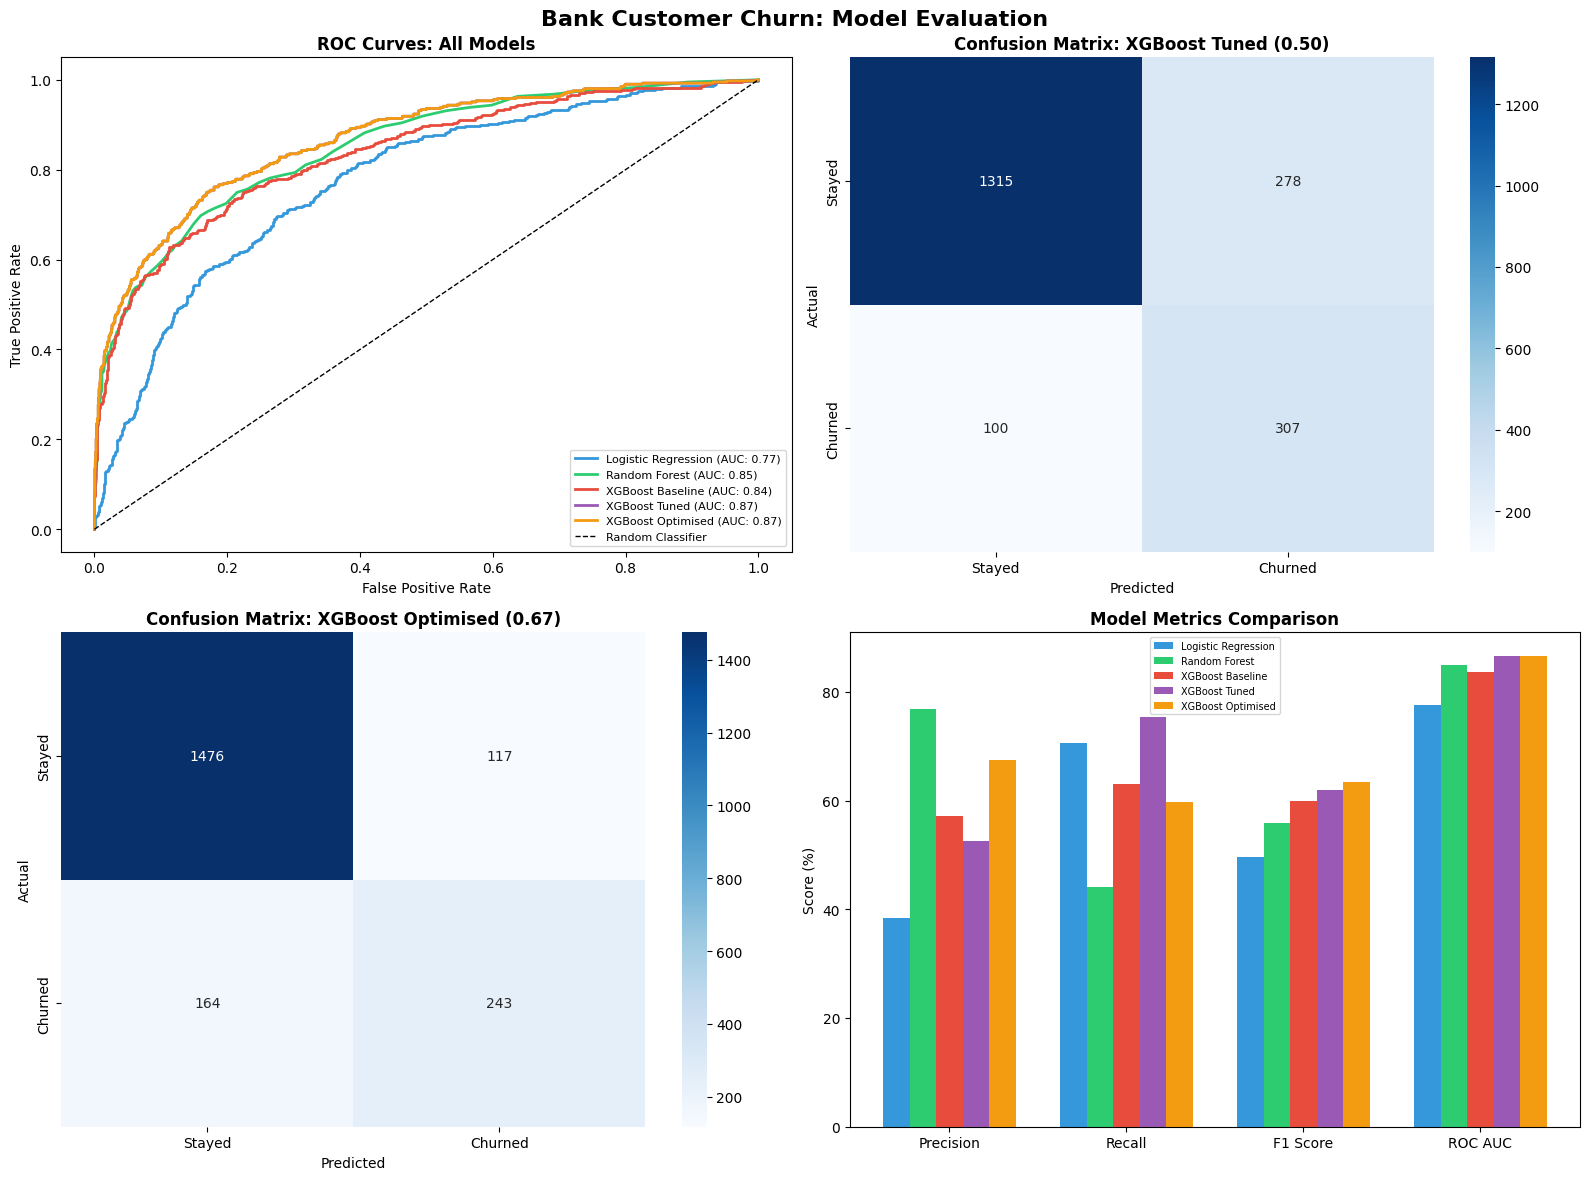

Figures saved to figures/analysis2_model_evaluation.png

XGBoost Tuned confusion matrix:
True Negatives: 1315 | False Positives: 278
False Negatives: 100 | True Positives: 307

XGBoost Optimised confusion matrix:
True Negatives: 1476 | False Positives: 117
False Negatives: 164 | True Positives: 243


In [35]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bank Customer Churn: Model Evaluation', fontsize=16, fontweight='bold')

# Define models for plotting
models = {
    'Logistic Regression': (lr_prob, lr_pred),
    'Random Forest': (rf_prob, rf_pred),
    'XGBoost Baseline': (xgb_prob, xgb_pred),
    'XGBoost Tuned': (xgb_tuned_prob, xgb_tuned_pred),
    'XGBoost Optimised': (xgb_tuned_prob, xgb_optimised_pred)
}

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

# Plot 1: ROC curves for all models
for (name, (prob, pred)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0, 0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC: {auc:.2f})')

axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0, 0].set_title('ROC Curves: All Models', fontweight='bold')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].legend(fontsize=8)

# Plot 2: Confusion matrix for XGBoost Tuned
cm_tuned = confusion_matrix(y_test, xgb_tuned_pred)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix: XGBoost Tuned (0.50)', fontweight='bold')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Plot 3: Confusion matrix for XGBoost Optimised
cm_optimised = confusion_matrix(y_test, xgb_optimised_pred)
sns.heatmap(cm_optimised, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            ax=axes[1, 0])
axes[1, 0].set_title('Confusion Matrix: XGBoost Optimised (0.67)', fontweight='bold')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# Plot 4: Metrics comparison bar chart
metrics_plot = metrics_final[['Precision', 'Recall', 'F1 Score', 'ROC AUC']]
x = np.arange(len(metrics_plot.columns))
width = 0.15
model_names = metrics_plot.index.tolist()

for i, (model, color) in enumerate(zip(model_names, colors)):
    axes[1, 1].bar(x + i * width, metrics_plot.loc[model],
                   width=width, label=model, color=color)

axes[1, 1].set_title('Model Metrics Comparison', fontweight='bold')
axes[1, 1].set_xticks(x + width * 2)
axes[1, 1].set_xticklabels(metrics_plot.columns)
axes[1, 1].set_ylabel('Score (%)')
axes[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('figures/analysis2_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figures saved to figures/analysis2_model_evaluation.png")
print(f"\nXGBoost Tuned confusion matrix:")
print(f"True Negatives: {cm_tuned[0,0]} | False Positives: {cm_tuned[0,1]}")
print(f"False Negatives: {cm_tuned[1,0]} | True Positives: {cm_tuned[1,1]}")
print(f"\nXGBoost Optimised confusion matrix:")
print(f"True Negatives: {cm_optimised[0,0]} | False Positives: {cm_optimised[0,1]}")
print(f"False Negatives: {cm_optimised[1,0]} | True Positives: {cm_optimised[1,1]}")

## Section 8: SHAP Value Analysis

SHAP (SHapley Additive exPlanations) values were calculated for the tuned XGBoost model to identify which features drove churn predictions and in which direction. The summary plot ranks features by mean absolute SHAP value and the beeswarm plot shows the direction and magnitude of each feature's impact across all customers in the test set.

SHAP values shape: (2000, 14)
Test set shape: (2000, 14)
Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Balance_to_Salary', 'Products_Activity', 'Age_Balance']


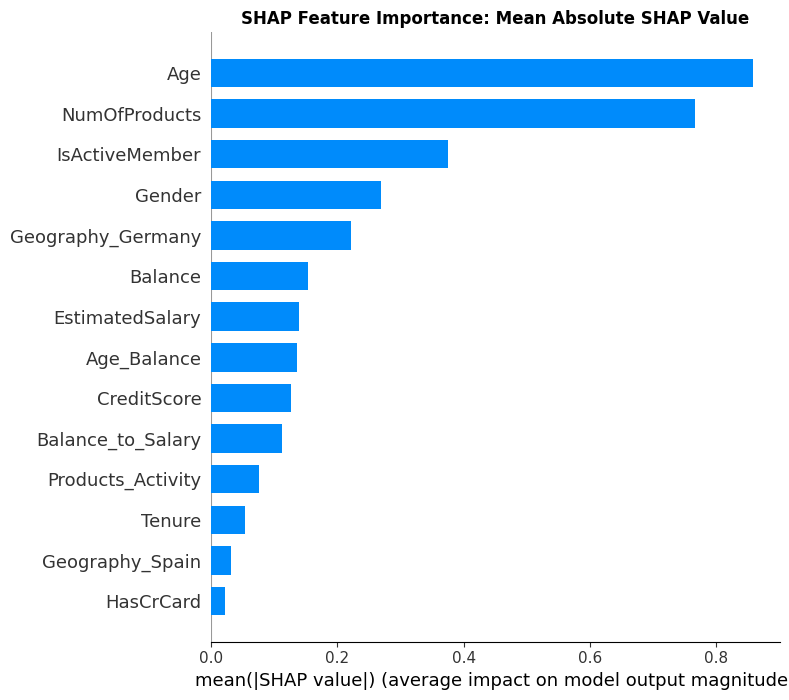

SHAP summary bar plot saved


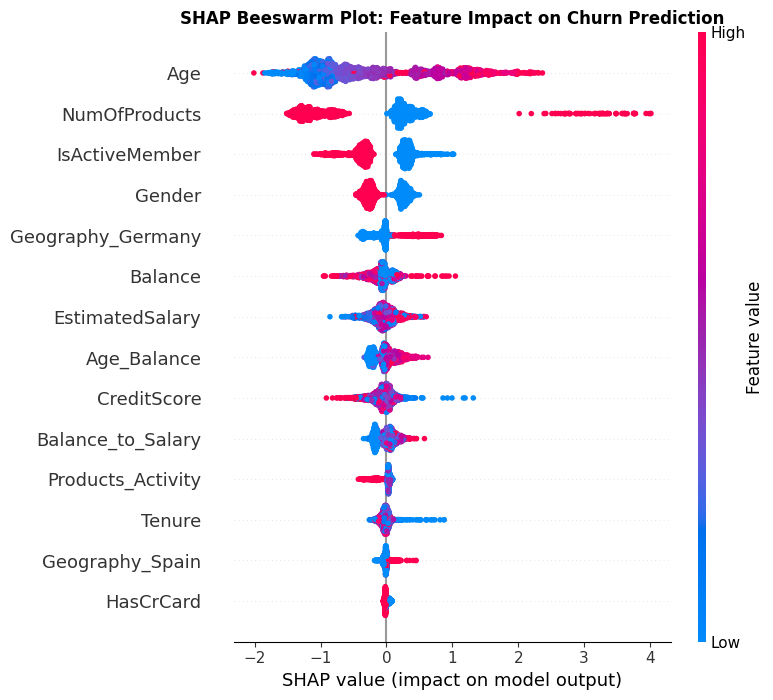

SHAP beeswarm plot saved

Top 5 features by mean absolute SHAP value:
          Feature  Mean SHAP
              Age       0.86
    NumOfProducts       0.77
   IsActiveMember       0.38
           Gender       0.27
Geography_Germany       0.22


In [36]:

# Initialise SHAP explainer
explainer = shap.TreeExplainer(xgb_tuned)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Features: {X_test.columns.tolist()}")

# Plot 1: SHAP summary bar plot — mean absolute SHAP values
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance: Mean Absolute SHAP Value', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/analysis3_shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary bar plot saved")

# Plot 2: SHAP beeswarm plot — direction and magnitude
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    plot_type='dot',
    show=False
)
plt.title('SHAP Beeswarm Plot: Feature Impact on Churn Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/analysis3_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP beeswarm plot saved")

print(f"\nTop 5 features by mean absolute SHAP value:")
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean SHAP', ascending=False)
print(shap_importance.head().to_string(index=False))

## Section 8b: Single Customer Prediction Explained

A SHAP waterfall plot was generated for the customer with the highest predicted churn probability in the test set. The plot shows the contribution of each feature to that individual prediction, illustrating how the model arrived at its decision and which factors placed this customer at the highest risk of churning.

Highest risk customer index: 586
Predicted churn probability: 99.8%
Actual outcome: Churned

Customer profile:
CreditScore Gender Age Tenure   Balance NumOfProducts HasCrCard IsActiveMember EstimatedSalary Geography_Germany Geography_Spain Balance_to_Salary Products_Activity Age_Balance
        547      1  55      4 111362.76             3         1              0        16922.28              True           False              2.03                 0  6124951.80


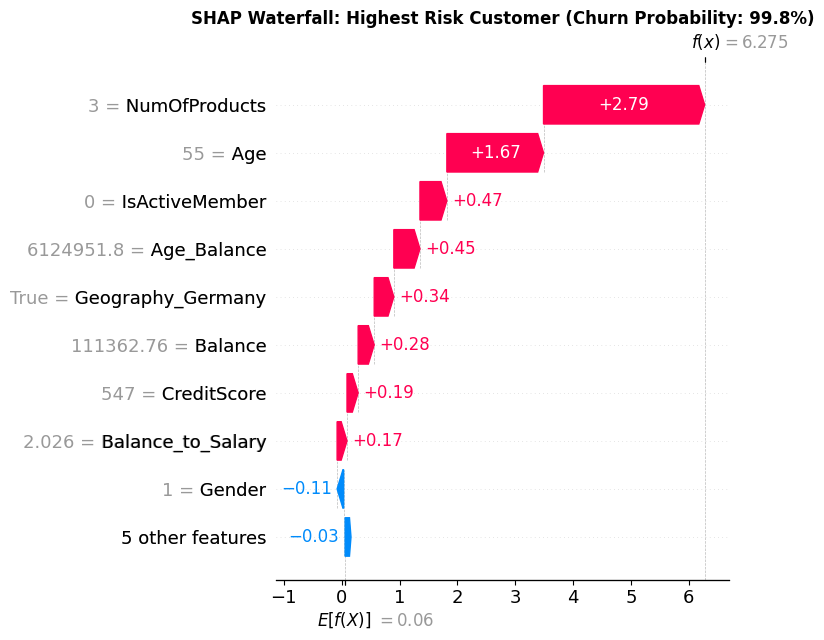


SHAP waterfall plot saved to figures/analysis4_shap_waterfall.png


In [37]:

# Identify customer with highest predicted churn probability
highest_risk_idx = np.argmax(xgb_tuned_prob)
highest_risk_prob = xgb_tuned_prob[highest_risk_idx]

print(f"Highest risk customer index: {highest_risk_idx}")
print(f"Predicted churn probability: {highest_risk_prob*100:.1f}%")
print(f"Actual outcome: {'Churned' if y_test.iloc[highest_risk_idx] == 1 else 'Stayed'}")

print(f"\nCustomer profile:")
print(X_test.iloc[highest_risk_idx].to_frame().T.to_string(index=False))

# Calculate SHAP explanation for this customer
explainer_v2 = shap.TreeExplainer(xgb_tuned)
shap_explanation = explainer_v2(X_test)

# Plot waterfall for highest risk customer
plt.figure(figsize=(10, 8))
shap.plots.waterfall(
    shap_explanation[highest_risk_idx],
    show=False
)
plt.title(f'SHAP Waterfall: Highest Risk Customer (Churn Probability: {highest_risk_prob*100:.1f}%)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('figures/analysis4_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSHAP waterfall plot saved to figures/analysis4_shap_waterfall.png")

## Section 9: Summary Findings

### Dataset Overview
The analysis was conducted on a dataset of 10,000 retail banking customers across three geographies: France, Germany and Spain. The dataset contained no missing values or duplicate records. The target variable was binary, with 79.6% of customers having stayed and 20.4% having churned, representing a moderately imbalanced classification problem.

### Exploratory Data Analysis
Several strong patterns were identified during exploratory analysis. Germany recorded a churn rate of 32.4%, approximately double that of France at 16.2% and Spain at 16.7%, suggesting a geography-specific retention problem requiring targeted investigation. Customers aged 40 to 50 were found to churn at a disproportionately higher rate compared to younger age groups, identifying a high-value demographic at elevated risk. Customers holding three or four products recorded churn rates of 82.7% and 100% respectively, a counterintuitive finding suggesting that high product holding may reflect customer dissatisfaction or cross-selling pressure rather than loyalty. Inactive members churned at 26.9% compared to 14.3% for active members, confirming that engagement is a strong protective factor against churn. Female customers churned at 25.1% compared to 16.5% for male customers, a meaningful gap with potential implications for targeted retention strategy.

### Zero Balance and High Value Analysis
Over a third of customers held a zero account balance, yet this segment recorded a churn rate of only 13.8%, well below the overall average of 20.4%. Customers with a positive balance churned at 24.1%, nearly double the rate of zero balance customers, confirming that the bank is losing its most financially significant relationships at a disproportionate rate. Churned customers held an average balance of £91,109 compared to £72,745 for customers who stayed, a gap of over £18,000 per customer. Among high value customers, defined as those in the top 25% by balance with accounts above £127,644, the churn rate reached 23.7%. Germany amplified this further, with 29.0% of high value German customers churning, representing the single most financially damaging segment identified in the entire analysis.

### Dormant Account Analysis
A dormant account was defined as a customer holding a zero balance, classified as inactive and holding only one product. Of the 10,000 customers in the dataset, 473 met this definition, representing 4.7% of the total. Contrary to expectation, dormant customers did not show a lower churn rate than the overall population. They churned at 47.1%, more than double the overall rate of 20.4% and significantly higher than the engaged customer churn rate of 19.0%. This finding reframes the dormant segment entirely. These are not abandoned accounts quietly sitting on the books. They are customers who have effectively already decided to leave and have not yet formally closed their accounts. A proactive re-engagement programme targeting this segment before formal account closure could represent a material retention opportunity. Notably, all 473 dormant accounts were concentrated in France and Spain. Germany had no dormant accounts by this definition, suggesting that disengaged German customers leave immediately rather than remaining on zero balance, further reinforcing the urgency of the German retention problem.

### Model Development
Three classification models were trained and evaluated: Logistic Regression as a baseline, Random Forest as an ensemble method and XGBoost as the primary model. Class imbalance was addressed using class weight balancing for Logistic Regression and Random Forest, and scale position weight for XGBoost. The tuned XGBoost model achieved a ROC-AUC of 86.6% and an F1 score of 61.9% at the default threshold. Following threshold optimisation, the decision boundary was raised to 0.67, improving precision from 52.5% to 67.5% and overall accuracy to 86.0%, with F1 improving to 63.4%. The choice between the two thresholds represents a business decision: the lower threshold prioritises recall and is suited to mass retention campaigns, while the higher threshold prioritises precision and is better suited to costly individual interventions.

### SHAP Interpretation
SHAP value analysis confirmed that age was the single most influential predictor of churn, followed closely by number of products held and membership activity status. Geography, specifically Germany, and gender also contributed meaningfully to predictions. The engineered features Age Balance and Balance to Salary both appeared in the SHAP waterfall for the highest risk customer, validating the feature engineering decisions made in Section 6. The highest risk customer in the test set was a 55 year old inactive German customer holding three products with a predicted churn probability of 99.8%, who was confirmed to have churned, demonstrating strong model precision on extreme cases.

### Business Recommendations
Based on the findings, six retention interventions are recommended. First, a targeted retention programme should be developed for customers aged 40 to 50, particularly those who are inactive or hold three or more products. Second, the German market warrants a dedicated investigation into the drivers of its elevated churn rate, which may reflect competitive, pricing or service quality factors specific to that region. Third, high value German customers should be treated as an immediate priority given that nearly one in three are churning and each represents an average balance loss of over £149,000. Fourth, product holding strategy should be reviewed, as customers with three or more products show extreme churn rates that suggest the current cross-selling approach may be counterproductive. Fifth, member activity should be monitored as an early warning indicator, with proactive outreach triggered for customers who become inactive before churn occurs. Sixth, the 473 dormant accounts identified in France and Spain should be prioritised for immediate re-engagement given their 47.1% churn rate, as these customers are highly likely to be in the process of leaving and represent a recoverable retention opportunity at relatively low intervention cost.

## Section 10: Conclusions and Limitations

### Conclusions
This project set out to answer a fundamental business question: which customers are most likely to leave, and why? The analysis delivers a clear and actionable answer supported by machine learning, statistical evidence and transparent model interpretation.

Customer churn in retail banking is not evenly distributed. It is concentrated in identifiable, reachable segments. Older customers, those holding three or more products, inactive members and customers based in Germany account for a disproportionate share of churn risk. These are not abstract statistical patterns. They are real customers with names, account numbers and relationship managers, and they can be contacted before they leave.

The financial stakes are significant. Churned customers in this dataset held an average balance of £91,109, compared to £72,745 for customers who stayed, a difference of over £18,000 per customer. In a bank with one million customers and a 20% churn rate, that represents a potential balance outflow running into the billions annually. High value German customers, those in the top 25% by balance, are churning at 29.0%, the highest rate of any segment identified. Each of these customers represents an average balance of over £149,000. Retaining even a fraction of this segment would deliver material financial benefit far exceeding the cost of any targeted retention programme.

The tuned XGBoost model achieved a ROC-AUC of 86.6%, meaning the bank can now rank its entire customer base by churn risk with strong confidence. Two deployment options are available. A recall-focused threshold identifies the broadest possible set of at-risk customers and is suited to low-cost mass outreach campaigns such as email, in-app messaging or automated offers. A precision-focused threshold reduces false alarms and is suited to high-cost individual interventions such as personal calls from relationship managers or bespoke retention packages. The choice between them is a business decision, not a technical one, and this project provides both with full transparency on the trade-offs.

The immediate recommended actions are three. First, deploy the model to score the live customer base and identify the top 500 highest-risk customers for immediate relationship manager review, prioritising Germany and customers aged 40 to 50 with multiple products. Second, commission a dedicated investigation into the German market to understand whether the elevated churn rate reflects pricing, competition, service quality or product fit, as no model can solve a structural market problem. Third, review the cross-selling strategy for customers holding three or more products, as the extreme churn rates in this segment suggest that product volume may be driving dissatisfaction rather than loyalty.

### Limitations
The following limitations should be considered before moving this model into production.

The dataset does not include a time dimension. Churn patterns change over time in response to competitor activity, interest rate movements and macroeconomic conditions. A model trained on a static snapshot requires regular retraining on fresh data to remain reliable and should be monitored for performance drift after deployment.

Behavioural data is absent. In a live banking environment, the strongest early indicators of churn are typically complaints lodged, digital login frequency declining, direct debits cancelled and products closed. None of these signals are present in this dataset. Integrating transactional and behavioural data into a second model iteration would likely deliver a meaningful improvement in both predictive accuracy and lead time before churn occurs.

The drivers of Germany's elevated churn rate cannot be explained by this dataset alone. The model identifies Germany as a high-risk geography but cannot determine whether this reflects local competition, pricing gaps, service quality issues or demographic factors. A dedicated market analysis combining this model's outputs with qualitative customer research would be required to design an effective intervention.

The dormant account finding introduces an important operational consideration. The 47.1% churn rate among dormant customers suggests that account status alone is a powerful early warning signal that does not require a machine learning model to act upon. A simple rule-based alert triggering outreach to any customer who becomes zero balance, inactive and single product simultaneously could deliver meaningful retention value independently of the predictive model developed here. Integrating such a rule into the bank's CRM system would be a low-cost, high-return first deployment step.

The zero balance segment more broadly warrants further investigation before any retention strategy is finalised. While dormant accounts have been isolated and analysed separately, the remaining zero balance customers who do not meet the full dormancy definition may still represent a heterogeneous group including new customers, seasonal savers and customers consolidating accounts elsewhere. Distinguishing between these sub-segments would sharpen the precision of any retention intervention.

Finally, model performance was evaluated on a single train-test split. While stratified sampling preserved class balance, a production deployment should include cross-validated performance assessment across multiple data splits, alongside a formal model governance review appropriate to the regulatory environment in which the bank operates.

In [1]:
# Rename figures to correct sequential numbering

import os

renames = {
    'figures/analysis2_model_evaluation.png': 'figures/analysis4_model_evaluation.png',
    'figures/analysis3_shap_summary_bar.png': 'figures/analysis5_shap_summary_bar.png',
    'figures/analysis3_shap_beeswarm.png': 'figures/analysis6_shap_beeswarm.png',
    'figures/analysis4_shap_waterfall.png': 'figures/analysis7_shap_waterfall.png'
}

for old, new in renames.items():
    if os.path.exists(old):
        os.rename(old, new)
        print(f"Renamed: {old} → {new}")
    else:
        print(f"Not found: {old}")

print("\nAll figures renamed successfully")

Renamed: figures/analysis2_model_evaluation.png → figures/analysis4_model_evaluation.png
Renamed: figures/analysis3_shap_summary_bar.png → figures/analysis5_shap_summary_bar.png
Renamed: figures/analysis3_shap_beeswarm.png → figures/analysis6_shap_beeswarm.png
Renamed: figures/analysis4_shap_waterfall.png → figures/analysis7_shap_waterfall.png

All figures renamed successfully
